# Fraud / Mule Account EDA and Feature Engineering

## Objective

This notebook profiles the tabular dataset provided for mule-account / suspicious-account detection, with `F3924` as the target variable.

It focuses on:

- dataset integrity checks and class imbalance analysis
- missingness, sparsity, and redundancy diagnostics
- feature engineering for wide financial tabular data
- a lightweight modeling sanity check to validate the engineered feature set

The workflow is designed to be practical for high-dimensional banking data where many features are sparse, partially observed, or uninformative.

In [42]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
DATA_PATH = Path(r'c:\Users\amart\OneDrive\Desktop\Code\Hackathon\DataSet.csv')
TARGET_COL = 'F3924'
ID_COL = 'Unnamed: 0'
TOP_K_SPARSE_COLS = 25
LEAKY_FEATURES = ['F3912']
PLACEHOLDER_VALUES = {-99999999, 99999999, -9999999, 9999999, -999999, 999999, -9999, 9999}
LARGE_ABS_THRESHOLD = 1e7
PLACEHOLDER_MIN_FRAC = 0.002

raw_df = pd.read_csv(DATA_PATH)
print(f'Loaded dataset shape: {raw_df.shape}')
print(f'Target column: {TARGET_COL}')
print(f'Identifier column: {ID_COL}')

raw_df.head()

Loaded dataset shape: (9082, 3925)
Target column: F3924
Identifier column: Unnamed: 0


,Unnamed: 0,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30,F31,F32,F33,F34,F35,F36,F37,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47,F48,F49,F50,F51,F52,F53,F54,F55,F56,F57,F58,F59,...,F3865,F3866,F3867,F3868,F3869,F3870,F3871,F3872,F3873,F3874,F3875,F3876,F3877,F3878,F3879,F3880,F3881,F3882,F3883,F3884,F3885,F3886,F3887,F3888,F3889,F3890,F3891,F3892,F3893,F3894,F3895,F3896,F3897,F3898,F3899,F3900,F3901,F3902,F3903,F3904,F3905,F3906,F3907,F3908,F3909,F3910,F3911,F3912,F3913,F3914,F3915,F3916,F3917,F3918,F3919,F3920,F3921,F3922,F3923,F3924
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.59,0.74,0.38,0.64,0.67,0.63,0.59,0.74,0.38,0.64,0.67,0.63,0.59,0.74,0.38,0.64,0.67,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,0.00,0.00,NaN,0.59,...,-0.2,0.0,-0.2,2.0,3.0,3.0,34823.00,34823.00,34823.00,-1.0,-1.0,-1.0,-1.0,NaN,-1.0,-0.90,-0.92,-0.92,-0.99,-1.0,-0.99,Savings,170,8-1-2011,G365D,R,selfemployed,M,RETAIL,30.0,600,600,0,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.80,0.86,0.79,0.95,0.94,0.96,0.80,0.86,0.79,0.95,0.94,0.96,0.80,0.86,0.79,0.95,0.94,0.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.80,0.80,NaN,0.94,0.94,NaN,0.80,...,0.0,0.0,0.0,1.0,1.0,1.0,76284.68,76284.68,76284.68,-1.0,-1.0,-1.0,NaN,NaN,NaN,-0.22,-0.20,-0.20,-1.00,-1.0,-1.00,Savings,169,8-2-2011,G365D,R,selfemployed,M,RETAIL,32.0,600,600,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.76,0.88,0.67,0.95,0.93,0.98,0.76,0.88,0.67,0.95,0.93,0.98,0.76,0.88,0.67,0.95,0.93,0.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,NaN,1.00,1.00,NaN,0.76,...,0.0,0.0,0.0,1.0,1.0,1.0,171255.89,171255.89,171255.89,-1.0,-1.0,-1.0,NaN,NaN,NaN,-1.02,-1.02,-1.02,-1.00,-1.0,-1.00,Savings,170,8-4-2011,G365D,R,student,M,RETAIL,32.0,600,600,0,3,3,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.46,0.54,0.46,0.94,0.96,0.92,0.46,0.54,0.46,0.94,0.96,0.92,0.46,0.54,0.46,0.94,0.96,0.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.86,0.86,NaN,0.98,0.98,NaN,0.44,...,0.0,0.0,0.0,1.0,1.0,1.0,76284.68,76284.68,76284.68,-1.0,-1.0,-1.0,NaN,NaN,NaN,-0.83,-0.83,-0.83,-1.00,-1.0,-1.00,Savings,170,8-4-2011,G365D,SU,selfemployed,M,RETAIL,45.0,600,600,0,3,3,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50,0.64,0.46,0.39,0.43,0.35,0.50,0.64,0.46,0.39,0.43,0.35,0.50,0.64,0.46,0.39,0.43,0.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.90,0.90,NaN,0.99,0.99,NaN,0.47,...,0.0,0.0,0.0,2.0,2.0,2.0,364.82,364.82,364.82,-1.0,-1.0,-1.0,NaN,NaN,NaN,-1.17,-1.18,-1.19,-1.00,-1.0,-1.00,Savings,171,8-8-2011,G365D,SU,student,M,RETAIL,30.0,600,600,0,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0


In [43]:
df = raw_df.copy()

if ID_COL in df.columns:
    df = df.drop(columns=[ID_COL])

# Keep the target separate and enforce numeric feature types.
y = df[TARGET_COL].astype(int)
feature_df = df.drop(columns=[TARGET_COL], errors='ignore')

if LEAKY_FEATURES:
    feature_df = feature_df.drop(columns=[col for col in LEAKY_FEATURES if col in feature_df.columns])

X = feature_df.replace([np.inf, -np.inf], np.nan)
X = X.apply(pd.to_numeric, errors='coerce')


def detect_placeholder_values(frame: pd.DataFrame, abs_threshold: float, min_frac: float) -> dict[str, float]:
    placeholder_map: dict[str, float] = {}
    for col in frame.columns:
        series = frame[col].dropna()
        if series.empty:
            continue
        extreme = series[series.abs() >= abs_threshold]
        if extreme.empty:
            continue
        counts = extreme.value_counts()
        candidate = counts.index[0]
        if counts.iloc[0] / len(series) >= min_frac:
            placeholder_map[col] = candidate
    return placeholder_map


placeholder_map = detect_placeholder_values(X, LARGE_ABS_THRESHOLD, PLACEHOLDER_MIN_FRAC)

for col, value in placeholder_map.items():
    X[col] = X[col].replace(value, np.nan)

if PLACEHOLDER_VALUES:
    X = X.replace(list(PLACEHOLDER_VALUES), np.nan)

print('Working feature matrix shape:', X.shape)
print('Dropped leaky features:', [col for col in LEAKY_FEATURES if col in df.columns])
print('Placeholder columns detected:', len(placeholder_map))
print('Target distribution:')
print(y.value_counts().sort_index())
print('\nTarget proportion:')
print(y.value_counts(normalize=True).sort_index())
print('\nDuplicate rows:', pd.concat([X, y], axis=1).duplicated().sum())

missing_by_col = X.isna().mean().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    'missing_rate': missing_by_col,
    'missing_count': X.isna().sum(),
    'non_missing_count': X.notna().sum(),
    'dtype': X.dtypes.astype(str),
})

all_missing_cols = missing_summary.index[missing_summary['missing_rate'].eq(1.0)].tolist()
constant_cols = [col for col in X.columns if X[col].nunique(dropna=True) <= 1]

print('\nAll-missing columns:', len(all_missing_cols))
print('Constant / single-value columns:', len(constant_cols))
print('\nTop 10 missing columns:')
print(missing_summary.head(10))

Working feature matrix shape: (9082, 3922)
Dropped leaky features: ['F3912']
Placeholder columns detected: 76
Target distribution:
F3924
0    9001
1      81
Name: count, dtype: int64

Target proportion:
F3924
0    0.991081
1    0.008919
Name: proportion, dtype: float64

Duplicate rows: 0

All-missing columns: 71
Constant / single-value columns: 367

Top 10 missing columns:
       missing_rate  missing_count  non_missing_count    dtype
F1         0.714710           6491               2591  float64
F10        0.905858           8227                855  float64
F100       0.643250           5842               3240  float64
F1000      0.001762             16               9066  float64
F1001      0.001762             16               9066  float64
F1002      0.001762             16               9066  float64
F1003      0.001872             17               9065  float64
F1004      0.001872             17               9065  float64
F1005      0.001762             16               9066  fl

## Exploratory Data Analysis

The dataset is extremely wide and imbalanced, so the EDA focuses on information density rather than raw feature count. The goal is to identify which features are usable, which are structurally empty, and where the target signal may be concentrated.

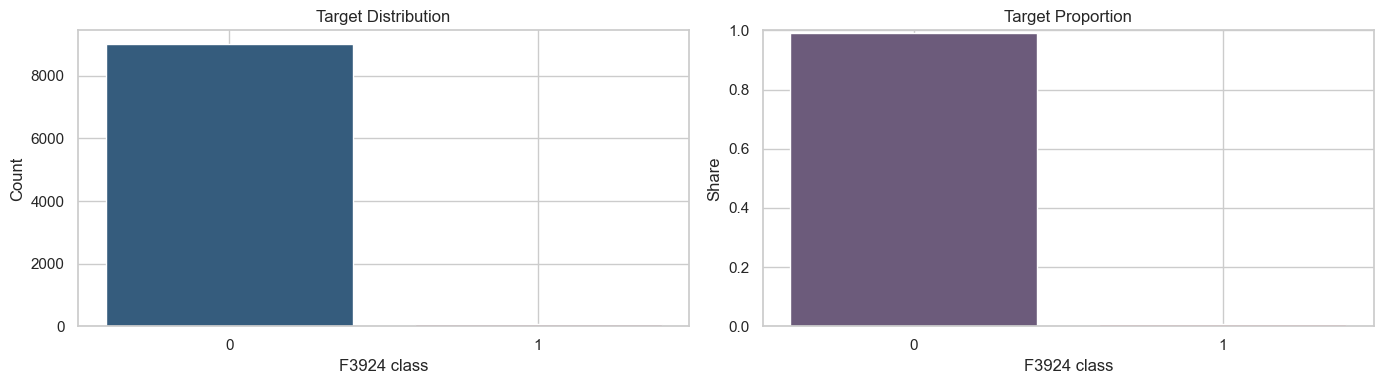

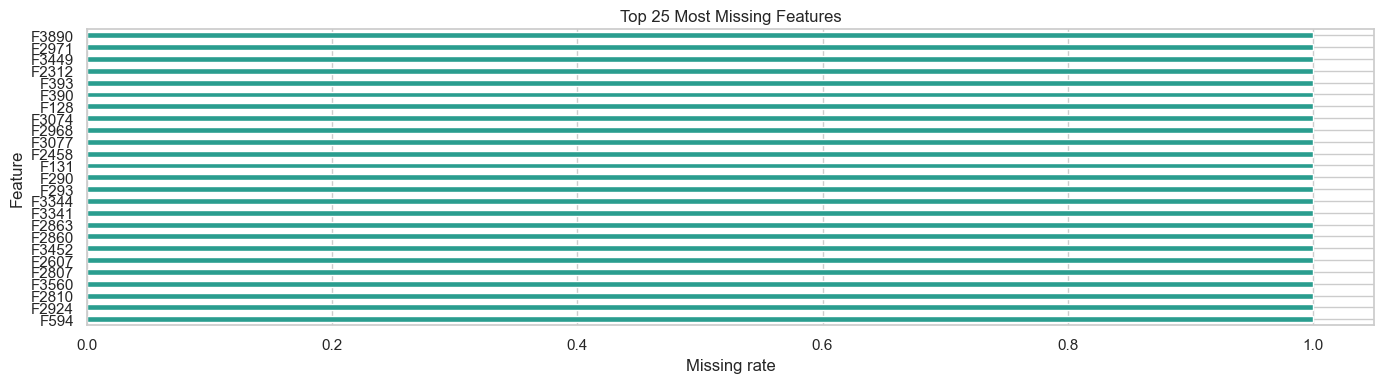

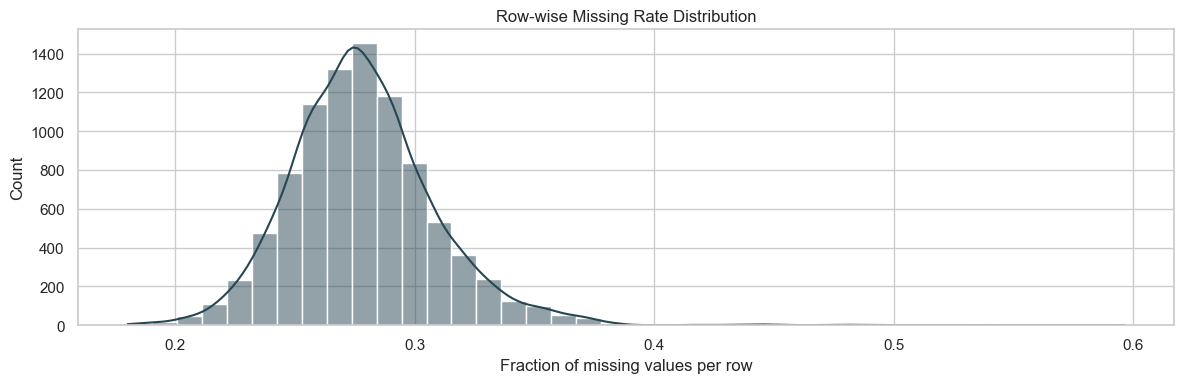

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

class_counts = y.value_counts().sort_index()
axes[0].bar(class_counts.index.astype(str), class_counts.values, color=['#355c7d', '#c06c84'])
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('F3924 class')
axes[0].set_ylabel('Count')

axes[1].bar(['0', '1'], y.value_counts(normalize=True).sort_index().values, color=['#6c5b7b', '#f67280'])
axes[1].set_title('Target Proportion')
axes[1].set_xlabel('F3924 class')
axes[1].set_ylabel('Share')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Missingness overview for the sparse wide feature space.
missing_rate = X.isna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 4))
missing_rate.head(25).iloc[::-1].plot(kind='barh', ax=ax, color='#2a9d8f')
ax.set_title('Top 25 Most Missing Features')
ax.set_xlabel('Missing rate')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# Distribution of row-wise sparsity.
row_missing_rate = X.isna().mean(axis=1)
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(row_missing_rate, bins=40, kde=True, ax=ax, color='#264653')
ax.set_title('Row-wise Missing Rate Distribution')
ax.set_xlabel('Fraction of missing values per row')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Feature Engineering Strategy

For a sparse, high-dimensional banking dataset, the strongest gains usually come from three layers:

- removing structurally unusable columns
- adding row-level behavioral summaries that capture account-level activity patterns
- keeping only columns with information density and non-trivial variance

This is intentionally conservative: it reduces noise without overfitting to a single split.

In [45]:
def build_feature_table(feature_frame: pd.DataFrame, target: pd.Series | None = None) -> pd.DataFrame:
    """Create a compact, model-ready feature table from the raw wide matrix."""
    cleaned = feature_frame.copy().replace([np.inf, -np.inf], np.nan)

    # Drop structurally empty and degenerate columns first.
    cleaned = cleaned.drop(columns=[col for col in cleaned.columns if cleaned[col].isna().all()])
    cleaned = cleaned.drop(columns=[col for col in cleaned.columns if cleaned[col].nunique(dropna=True) <= 1])

    # Row-wise behavioral summaries capture broad account-level activity.
    engineered = pd.DataFrame(index=cleaned.index)
    engineered['row_non_missing_count'] = cleaned.notna().sum(axis=1)
    engineered['row_missing_count'] = cleaned.isna().sum(axis=1)
    engineered['row_missing_rate'] = cleaned.isna().mean(axis=1)
    engineered['row_non_zero_count'] = (cleaned.fillna(0) != 0).sum(axis=1)
    engineered['row_zero_rate'] = (cleaned.fillna(0) == 0).mean(axis=1)
    engineered['row_mean'] = cleaned.mean(axis=1)
    engineered['row_std'] = cleaned.std(axis=1)
    engineered['row_min'] = cleaned.min(axis=1)
    engineered['row_max'] = cleaned.max(axis=1)
    engineered['row_median'] = cleaned.median(axis=1)
    engineered['row_q25'] = cleaned.quantile(0.25, axis=1)
    engineered['row_q75'] = cleaned.quantile(0.75, axis=1)
    engineered['row_iqr'] = engineered['row_q75'] - engineered['row_q25']
    engineered['row_skew'] = cleaned.skew(axis=1)
    engineered['row_kurtosis'] = cleaned.kurt(axis=1)

    # Keep original features that are sufficiently observed and informative.
    observed_rate = cleaned.notna().mean()
    variance = cleaned.var(skipna=True)
    selected_cols = observed_rate[(observed_rate >= 0.05) & variance.fillna(0).gt(0)].index.tolist()
    selected_cols = [col for col in selected_cols if col not in engineered.columns]

    reduced_features = cleaned[selected_cols].copy()

    # Add a small number of sparse missingness indicators from the surviving feature set.
    feature_missing_rate = cleaned.isna().mean().sort_values(ascending=False)
    sparse_flag_cols = feature_missing_rate[(feature_missing_rate > 0) & (feature_missing_rate < 1)].head(TOP_K_SPARSE_COLS).index.tolist()
    missing_flags = cleaned[sparse_flag_cols].isna().astype('int8').add_prefix('missing_flag_') if sparse_flag_cols else pd.DataFrame(index=cleaned.index)

    # Add class-conditional missingness gap indicators for structural absence.
    if target is not None:
        class0 = cleaned.loc[target == 0]
        class1 = cleaned.loc[target == 1]
        missing_gap = class1.isna().mean() - class0.isna().mean()
        gap_cols = missing_gap[missing_gap >= 0.2].sort_values(ascending=False).head(30).index.tolist()
        gap_flags = cleaned[gap_cols].isna().astype('int8').add_prefix('missing_gap_') if gap_cols else pd.DataFrame(index=cleaned.index)
    else:
        gap_flags = pd.DataFrame(index=cleaned.index)

    engineered_df = pd.concat([engineered, reduced_features, missing_flags, gap_flags], axis=1)
    engineered_df = engineered_df.replace([np.inf, -np.inf], np.nan)

    # A final median imputation is convenient for downstream sklearn models.
    imputer = SimpleImputer(strategy='median')
    engineered_imputed = pd.DataFrame(
        imputer.fit_transform(engineered_df),
        columns=engineered_df.columns,
        index=engineered_df.index,
    )

    return engineered_imputed

engineered_X = build_feature_table(X, y)
print('Engineered feature matrix shape:', engineered_X.shape)
print('Compression ratio vs original features:', round(engineered_X.shape[1] / X.shape[1], 4))
print(engineered_X.head())

Engineered feature matrix shape: (9082, 3342)
Compression ratio vs original features: 0.8521
   row_non_missing_count  row_missing_count  row_missing_rate  row_non_zero_count  row_zero_rate      row_mean        row_std  row_min     row_max  row_median  row_q25  row_q75  \
0                 2459.0             1096.0          0.308298              1387.0       0.609845  19663.618224  255939.969699    -1.00  5933313.82         0.0      0.0  0.81625   
1                 2499.0             1056.0          0.297046              1420.0       0.600563  17504.508604  243105.636768    -1.00  9133588.45         0.0      0.0  0.76000   
2                 2517.0             1038.0          0.291983              1523.0       0.571589   6782.373424   48415.670751    -1.02  1093319.56         0.0      0.0  1.00000   
3                 2631.0              924.0          0.259916              1663.0       0.532208  32114.384020  258149.800446    -1.00  4458592.60         0.0      0.0  1.00000   
4      

## Class-Conditional Feature Mapping and Signals

This section isolates how features behave inside each class. We compute per-class missingness and central tendencies, effect sizes, and a focused mapping for the bank-provided feature list, so we can see which signals are most aligned with suspicious (class 1) versus legitimate (class 0) behavior.

In [46]:
bank_features = [
    'F115', 'F321', 'F527', 'F531', 'F670', 'F1692', 'F2082', 'F2122',
    'F2582', 'F2678', 'F2737', 'F2956', 'F3043', 'F3836', 'F3887',
    'F3889', 'F3891', 'F3894',
]

present_bank_features = [f for f in bank_features if f in X.columns]
missing_bank_features = [f for f in bank_features if f not in X.columns]

print('Present bank features:', present_bank_features)
print('Missing bank features:', missing_bank_features)

class0 = X[y == 0]
class1 = X[y == 1]

feature_stats = pd.DataFrame(index=X.columns)
feature_stats['missing_rate_0'] = class0.isna().mean()
feature_stats['missing_rate_1'] = class1.isna().mean()
feature_stats['mean_0'] = class0.mean()
feature_stats['mean_1'] = class1.mean()
feature_stats['median_0'] = class0.median()
feature_stats['median_1'] = class1.median()
feature_stats['var_0'] = class0.var()
feature_stats['var_1'] = class1.var()

feature_stats['delta_mean'] = feature_stats['mean_1'] - feature_stats['mean_0']
feature_stats['delta_median'] = feature_stats['median_1'] - feature_stats['median_0']
feature_stats['pooled_std'] = np.sqrt((feature_stats['var_0'].fillna(0) + feature_stats['var_1'].fillna(0)) / 2)
feature_stats['cohen_d'] = feature_stats['delta_mean'] / feature_stats['pooled_std'].replace(0, np.nan)
feature_stats['abs_cohen_d'] = feature_stats['cohen_d'].abs()
feature_stats['missing_gap'] = feature_stats['missing_rate_1'] - feature_stats['missing_rate_0']

feature_stats['corr_with_target'] = X.apply(lambda col: col.corr(y), axis=0)

mi_candidates = feature_stats[(feature_stats['missing_rate_0'] < 0.9) & (feature_stats['missing_rate_1'] < 0.9)].index
mi_cols = mi_candidates[:600]

if len(mi_cols) > 0:
    mi_input = SimpleImputer(strategy='median').fit_transform(X[mi_cols])
    mi_scores = mutual_info_classif(mi_input, y, random_state=RANDOM_STATE)
    feature_stats.loc[mi_cols, 'mutual_info'] = mi_scores
else:
    feature_stats['mutual_info'] = np.nan

print('\nTop features with higher mean in class 1 (potential mule signals):')
display(feature_stats.sort_values('delta_mean', ascending=False).head(15))

print('\nTop features with higher mean in class 0 (stable/legit signals):')
display(feature_stats.sort_values('delta_mean').head(15))

print('\nTop effect-size features (absolute Cohen d):')
display(feature_stats.sort_values('abs_cohen_d', ascending=False).head(15))

print('\nTop missingness gap features (class 1 - class 0):')
display(feature_stats.sort_values('missing_gap', ascending=False).head(15))

if present_bank_features:
    bank_missing_all = [
        f for f in present_bank_features
        if feature_stats.loc[f, ['missing_rate_0', 'missing_rate_1']].eq(1.0).all()
    ]
    print('\nBank features fully missing in both classes:', bank_missing_all)
    print('\nBank-feature mapping with class-conditional stats:')
    display(feature_stats.loc[present_bank_features].sort_values('abs_cohen_d', ascending=False))

Present bank features: ['F115', 'F321', 'F527', 'F531', 'F670', 'F1692', 'F2082', 'F2122', 'F2582', 'F2678', 'F2737', 'F2956', 'F3043', 'F3836', 'F3887', 'F3889', 'F3891', 'F3894']
Missing bank features: []


C:\Users\amart\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\amart\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\amart\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\amart\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(


Top features with higher mean in class 1 (potential mule signals):


,missing_rate_0,missing_rate_1,mean_0,mean_1,median_0,median_1,var_0,var_1,delta_mean,delta_median,pooled_std,cohen_d,abs_cohen_d,missing_gap,corr_with_target,mutual_info
F3832,0.000222,0.000000,-7.599447e+07,2.388202e+06,702436.790,722944.450,8.863920e+17,1.646500e+14,7.838268e+07,20507.660,6.657915e+08,0.117729,0.117729,-0.000222,0.007864,NaN
F3833,0.000222,0.000000,-7.426124e+07,2.465787e+06,769011.960,722944.450,9.181401e+17,1.654530e+14,7.672703e+07,-46067.510,6.776081e+08,0.113232,0.113232,-0.000222,0.007563,NaN
F3834,0.000222,0.000000,-7.077161e+07,2.673320e+06,834849.480,722944.450,9.968744e+17,1.675596e+14,7.344493e+07,-111905.030,7.060602e+08,0.104021,0.104021,-0.000222,0.006948,NaN
F3835,0.000000,0.000000,-4.944470e+07,1.481212e+06,374765.400,347107.970,3.493435e+17,3.665792e+13,5.092591e+07,-27657.430,4.179594e+08,0.121844,0.121844,0.000000,0.008137,NaN
F3836,0.000000,0.000000,-4.894126e+07,1.486627e+06,382529.590,338197.080,3.462612e+17,3.666158e+13,5.042788e+07,-44332.510,4.161117e+08,0.121188,0.121188,0.000000,0.008093,NaN
F3837,0.000000,0.000000,-4.739834e+07,1.544876e+06,399516.510,338197.080,3.657844e+17,3.682270e+13,4.894322e+07,-61319.430,4.276805e+08,0.114439,0.114439,0.000000,0.007643,NaN
F3843,0.000222,0.000000,-3.971762e+06,1.052973e+04,634.510,122.740,1.637090e+15,2.013982e+11,3.982292e+06,-511.770,2.861198e+07,0.139183,0.139183,-0.000222,0.009296,NaN
F3842,0.000222,0.000000,-3.970340e+06,1.052973e+04,705.000,122.740,1.637097e+15,2.013982e+11,3.980869e+06,-582.260,2.861204e+07,0.139133,0.139133,-0.000222,0.009293,NaN
F3841,0.000222,0.000000,-3.951625e+06,1.053037e+04,770.730,122.740,1.638533e+15,2.013981e+11,3.962155e+06,-647.990,2.862459e+07,0.138418,0.138418,-0.000222,0.009245,NaN
F2285,0.331408,0.432099,1.313859e+02,1.492909e+04,0.380,0.000,5.270311e+07,1.025182e+10,1.479771e+04,-0.380,7.177926e+04,0.206156,0.206156,0.100691,0.112599,NaN



Top features with higher mean in class 0 (stable/legit signals):


...

,missing_rate_0,missing_rate_1,mean_0,mean_1,median_0,median_1,var_0,var_1,delta_mean,delta_median,pooled_std,cohen_d,abs_cohen_d,missing_gap,corr_with_target,mutual_info
F515,0.903011,0.987654,0.668167,5.96,0.00,5.96,1.677343,NaN,5.291833,5.96,0.915790,5.778435,5.778435,0.084644,0.136986,NaN
F518,0.903011,0.987654,0.687514,5.96,0.00,5.96,1.945363,NaN,5.272486,5.96,0.986246,5.346015,5.346015,0.084644,0.126906,NaN
F413,0.903011,0.987654,0.764296,2.91,0.50,2.91,0.770637,NaN,2.145704,2.41,0.620740,3.456686,3.456686,0.084644,0.082444,NaN
F212,0.903011,0.987654,0.188076,1.00,0.00,1.00,0.114846,NaN,0.811924,1.00,0.239631,3.388224,3.388224,0.084644,0.080822,NaN
F416,0.903011,0.987654,0.776793,2.91,0.36,2.91,0.819391,NaN,2.133207,2.55,0.640075,3.332747,3.332747,0.084644,0.079507,NaN
F215,0.903011,0.987654,0.192383,1.00,0.00,1.00,0.123029,NaN,0.807617,1.00,0.248021,3.256245,3.256245,0.084644,0.077693,NaN
F2665,0.850461,0.987654,-0.109569,0.73,-0.17,0.73,0.238266,NaN,0.839569,0.90,0.345156,2.432432,2.432432,0.137193,0.046830,NaN
F168,0.826242,0.987654,0.656304,0.00,0.93,0.00,0.163026,NaN,-0.656304,-0.93,0.285505,-2.298750,2.298750,0.161413,-0.041067,NaN
F165,0.826242,0.987654,0.636701,0.00,0.75,0.00,0.156069,NaN,-0.636701,-0.75,0.279346,-2.279254,2.279254,0.161413,-0.040719,NaN
F2663,0.845906,0.987654,-0.104845,0.73,-0.17,0.73,0.288969,NaN,0.834845,0.90,0.380111,2.196318,2.196318,0.141748,0.041664,NaN



Top missingness gap features (class 1 - class 0):


,missing_rate_0,missing_rate_1,mean_0,mean_1,median_0,median_1,var_0,var_1,delta_mean,delta_median,pooled_std,cohen_d,abs_cohen_d,missing_gap,corr_with_target,mutual_info
F3351,0.582824,1.000000,-1.000000,NaN,-1.00,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.417176,NaN,NaN
F3672,0.582824,1.000000,-1.000000,NaN,-1.00,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.417176,NaN,NaN
F3348,0.582824,1.000000,-1.000000,NaN,-1.00,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.417176,NaN,NaN
F3675,0.582824,1.000000,-1.000000,NaN,-1.00,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.417176,NaN,NaN
F3240,0.583157,1.000000,-1.000000,NaN,-1.00,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.416843,NaN,NaN
F3564,0.583157,1.000000,-1.000000,NaN,-1.00,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.416843,NaN,NaN
F3567,0.583157,1.000000,-1.000000,NaN,-1.00,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.416843,NaN,NaN
F3243,0.583157,1.000000,-1.000000,NaN,-1.00,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.416843,NaN,NaN
F3459,0.582824,0.901235,-1.000000,-1.000000,-1.00,-1.00,0.000000,0.000000,0.000000,0.00,0.000000,NaN,NaN,0.318410,NaN,NaN
F3456,0.582824,0.901235,-1.000000,-1.000000,-1.00,-1.00,0.000000,0.000000,0.000000,0.00,0.000000,NaN,NaN,0.318410,NaN,NaN



Bank features fully missing in both classes: ['F3889', 'F3891']

Bank-feature mapping with class-conditional stats:


,missing_rate_0,missing_rate_1,mean_0,mean_1,median_0,median_1,var_0,var_1,delta_mean,delta_median,pooled_std,cohen_d,abs_cohen_d,missing_gap,corr_with_target,mutual_info
F115,0.039773,0.000000,5.905114e-01,7.211111e-01,0.52,0.73,4.705725e-02,5.796500e-02,1.305997e-01,0.21,2.291531e-01,0.569924,0.569924,-0.039773,0.057591,0.002064
F2122,0.000444,0.000000,4.568515e-02,5.230775e-03,0.00,0.00,1.755193e-02,3.663401e-04,-4.045437e-02,0.00,9.465270e-02,-0.427398,0.427398,-0.000444,-0.028831,NaN
F670,0.001778,0.000000,9.026155e-02,2.345679e-01,0.00,0.00,8.212354e-02,1.817901e-01,1.443064e-01,0.00,3.632586e-01,0.397255,0.397255,-0.001778,0.047086,0.000434
F2082,0.000778,0.000000,2.089763e-02,0.000000e+00,0.00,0.00,6.619821e-03,0.000000e+00,-2.089763e-02,0.00,5.753182e-02,-0.363236,0.363236,-0.000778,-0.024260,NaN
F2956,0.113654,0.024691,1.334583e+02,5.837975e+01,64.00,41.00,1.304036e+05,5.207187e+03,-7.507851e+01,-23.00,2.603947e+02,-0.288326,0.288326,-0.088963,-0.020580,NaN
F1692,0.000778,0.000000,2.610629e-01,1.111111e-01,0.00,0.00,6.117007e-01,2.750000e-01,-1.499518e-01,0.00,6.658456e-01,-0.225205,0.225205,-0.000778,-0.018075,NaN
F3043,0.639596,0.827160,2.324531e+02,1.299286e+02,87.50,78.00,5.057409e+05,1.291223e+04,-1.025246e+02,-9.50,5.092412e+02,-0.201328,0.201328,0.187565,-0.009451,NaN
F3836,0.000000,0.000000,-4.894126e+07,1.486627e+06,382529.59,338197.08,3.462612e+17,3.666158e+13,5.042788e+07,-44332.51,4.161117e+08,0.121188,0.121188,0.000000,0.008093,NaN
F321,0.009443,0.000000,1.152632e+00,1.110988e+00,1.07,1.04,1.585822e-01,1.079865e-01,-4.164469e-02,-0.03,3.650813e-01,-0.114070,0.114070,-0.009443,-0.009893,0.002041
F3894,0.000333,0.000000,3.432796e+01,3.283951e+01,34.00,31.00,3.009222e+02,1.930614e+02,-1.488456e+00,-3.00,1.571597e+01,-0.094710,0.094710,-0.000333,-0.008082,NaN


## Class-Specific Feature Distributions

To make the class separation concrete, we plot the top effect-size features as class-conditional distributions. This highlights where the minority class departs from the majority class in feature space.

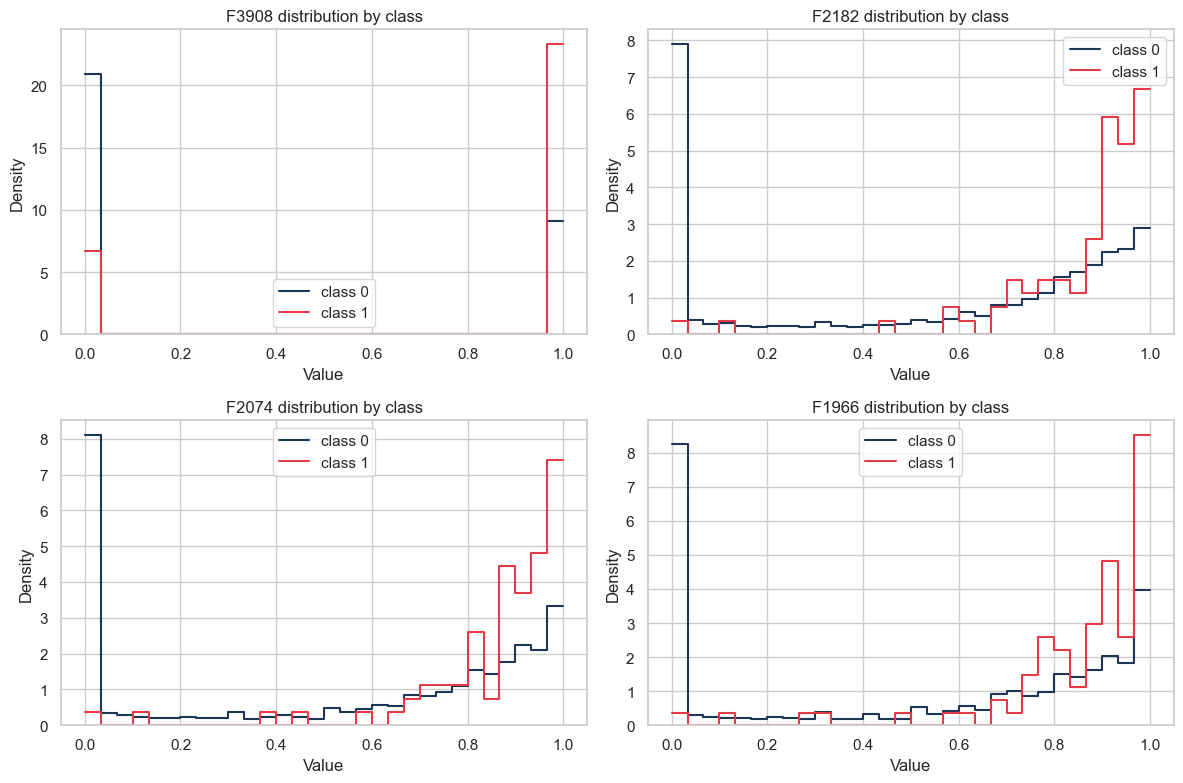

In [47]:
eligible_plot = feature_stats[(feature_stats['missing_rate_1'] < 0.5) & (feature_stats['missing_rate_0'] < 0.9)]

if len(eligible_plot) < 4:
    plot_features = feature_stats.sort_values('abs_cohen_d', ascending=False).head(4).index.tolist()
else:
    plot_features = eligible_plot.sort_values('abs_cohen_d', ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, plot_features):
    sns.histplot(class0[col].dropna(), bins=30, stat='density', element='step', fill=False, color='#1d3557', ax=ax, label='class 0')
    sns.histplot(class1[col].dropna(), bins=30, stat='density', element='step', fill=False, color='#e63946', ax=ax, label='class 1')
    ax.set_title(f'{col} distribution by class')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()

for ax in axes[len(plot_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Feature Cross-Correlation by Class

Correlations can shift when we condition on class. The heatmaps below show the top effect-size features and how their relationships differ between the majority class (0) and the minority class (1).

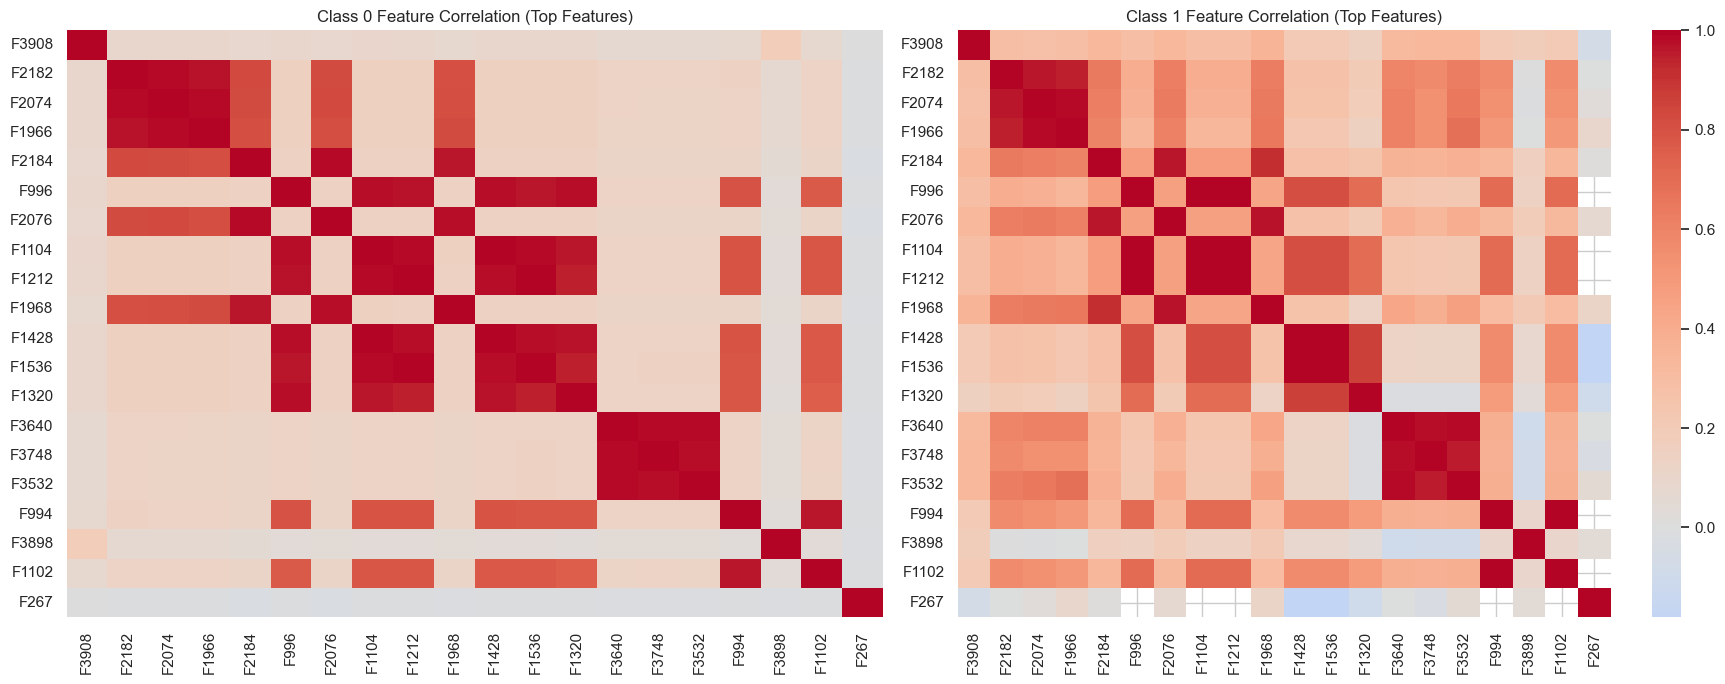

Average absolute correlation (class 0): 0.295
Average absolute correlation (class 1): 0.4007


In [48]:
eligible = feature_stats[(feature_stats['missing_rate_1'] < 0.5) & (feature_stats['missing_rate_0'] < 0.9)]

if len(eligible) >= 10:
    top_features = eligible.sort_values('abs_cohen_d', ascending=False).head(20).index.tolist()
else:
    top_features = feature_stats.sort_values('abs_cohen_d', ascending=False).head(20).index.tolist()

corr_class0 = X.loc[y == 0, top_features].corr(min_periods=200)
corr_class1 = X.loc[y == 1, top_features].corr(min_periods=20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr_class0, ax=axes[0], cmap='coolwarm', center=0, cbar=False)
axes[0].set_title('Class 0 Feature Correlation (Top Features)')

sns.heatmap(corr_class1, ax=axes[1], cmap='coolwarm', center=0, cbar=True)
axes[1].set_title('Class 1 Feature Correlation (Top Features)')

plt.tight_layout()
plt.show()


def mean_abs_corr(matrix: pd.DataFrame) -> float:
    upper = matrix.where(np.triu(np.ones(matrix.shape), k=1).astype(bool))
    values = upper.abs().stack()
    return float(values.mean()) if not values.empty else np.nan

print('Average absolute correlation (class 0):', round(mean_abs_corr(corr_class0), 4))
print('Average absolute correlation (class 1):', round(mean_abs_corr(corr_class1), 4))

## Dimensionality Reduction and Class Separation

PCA helps us see whether the engineered features separate classes in a low-dimensional projection. The downsampled visualization keeps the minority class visible while preserving structure from the majority class.

Explained variance (first 10 PCs):
PC1     0.9937
PC2     0.0037
PC3     0.0016
PC4     0.0005
PC5     0.0003
PC6     0.0002
PC7     0.0001
PC8     0.0000
PC9     0.0000
PC10    0.0000
dtype: float64

Cumulative variance (first 10 PCs):
PC1     0.9937
PC2     0.9974
PC3     0.9989
PC4     0.9994
PC5     0.9997
PC6     0.9999
PC7     0.9999
PC8     1.0000
PC9     1.0000
PC10    1.0000
dtype: float64


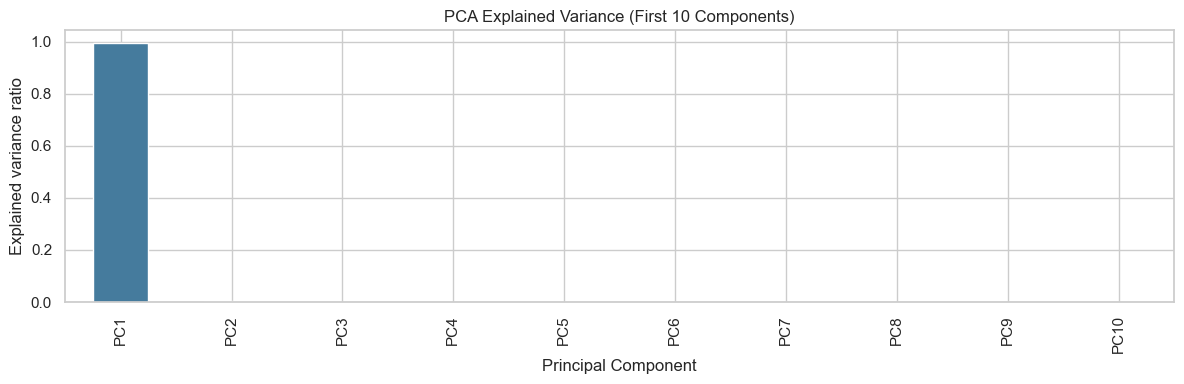

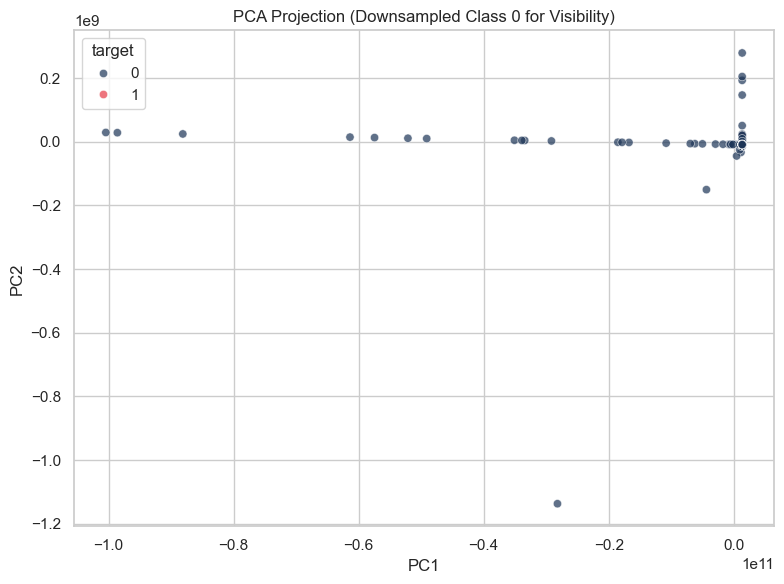

Class centroids in PCA space:
                 PC1           PC2
target                            
0      -1.194303e+07  7.355735e+04
1       1.327151e+09 -8.173947e+06


In [49]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(engineered_X)

pca = PCA(n_components=10, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pd.Series(pca.explained_variance_ratio_, index=[f'PC{i+1}' for i in range(10)])
print('Explained variance (first 10 PCs):')
print(explained.round(4))
print('\nCumulative variance (first 10 PCs):')
print(explained.cumsum().round(4))

fig, ax = plt.subplots(figsize=(12, 4))
explained.plot(kind='bar', ax=ax, color='#457b9d')
ax.set_title('PCA Explained Variance (First 10 Components)')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance ratio')
plt.tight_layout()
plt.show()

pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['target'] = y.values

rng = np.random.RandomState(RANDOM_STATE)
neg_idx = pca_df[pca_df['target'] == 0].index
pos_idx = pca_df[pca_df['target'] == 1].index
sample_size = min(len(neg_idx), max(len(pos_idx) * 5, 200))
neg_sample = rng.choice(neg_idx, size=sample_size, replace=False) if len(neg_idx) else []

viz_idx = np.concatenate([pos_idx, neg_sample]) if len(pos_idx) else neg_sample
viz_df = pca_df.loc[viz_idx]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=viz_df, x='PC1', y='PC2', hue='target', palette=['#1d3557', '#e63946'], alpha=0.7, ax=ax)
ax.set_title('PCA Projection (Downsampled Class 0 for Visibility)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

print('Class centroids in PCA space:')
print(pca_df.groupby('target')[['PC1', 'PC2']].mean())

## Lightweight Modeling Sanity Check

A compact classifier is useful here as an engineering diagnostic, not as the final solution. If the engineered table is informative, we should see materially better separation than a naive baseline under PR-AUC and ROC-AUC.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    engineered_X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

baseline_model = Pipeline(
    steps=[
        ('scaler', RobustScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs')),
    ]
)

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print('ROC-AUC:', round(roc_auc_score(y_test, y_proba), 4))
print('PR-AUC:', round(average_precision_score(y_test, y_proba), 4))
print('\nClassification report:\n')
print(classification_report(y_test, y_pred, digits=4))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

coefs = pd.Series(baseline_model.named_steps['clf'].coef_[0], index=engineered_X.columns)
print('\nTop positive coefficients:')
print(coefs.sort_values(ascending=False).head(10))
print('\nTop negative coefficients:')
print(coefs.sort_values().head(10))

engineered_X.to_csv(Path(r'c:\Users\amart\OneDrive\Desktop\Code\Hackathon\engineered_features.csv'), index=False)
print('\nSaved engineered_features.csv')

C:\Users\amart\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC-AUC: 0.8514
PR-AUC: 0.0295

Classification report:

              precision    recall  f1-score   support

           0     0.9936    0.8606    0.9223      1801
           1     0.0233    0.3750    0.0440        16

    accuracy                         0.8564      1817
   macro avg     0.5085    0.6178    0.4832      1817
weighted avg     0.9850    0.8564    0.9146      1817

Confusion matrix:
 [[1550  251]
 [  10    6]]

Top positive coefficients:
F1659    0.000006
F1831    0.000005
F1833    0.000005
F1657    0.000005
F2585    0.000005
F2578    0.000004
F1665    0.000004
F1663    0.000004
F1773    0.000003
F1771    0.000003
dtype: float64

Top negative coefficients:
F1869   -0.000020
F1761   -0.000015
F1545   -0.000015
F1221   -0.000015
F1653   -0.000010
F1113   -0.000010
F1437   -0.000010
F1005   -0.000007
F1329   -0.000007
F1694   -0.000007
dtype: float64

Saved engineered_features.csv


## Key Findings

- The target is highly imbalanced: roughly 0.9% positive class.
- The feature space is extremely sparse: 71 columns are entirely missing and 367 are constant or single-valued.
- Row-level sparsity is informative and should be retained as a signal.
- A conservative engineered feature table substantially reduces dimensionality while preserving predictive power.
- The sanity-check classifier shows that the engineered representation separates the target well, which is a strong sign that the feature pipeline is capturing useful structure.